# Notebook 1 — Exploration et nettoyage

Ce notebook part du fichier brut weatherAUS.csv.  
L'objectif est de poser rapidement le cadre, d'examiner la structure des valeurs manquantes puis de construire une version nettoyée du jeu de données.

À la fin, on enregistredf_clean.csv.

## Chargement et premier aperçu

On commence par une vue d'ensemble du dataset : dimensions, types, variable cible et part de valeurs manquantes.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from weather_cleaning import clean_weather_data
from weather_geo import build_location_missing_summary, build_missing_value_maps

df = pd.read_csv("weatherAUS.csv")
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print(df.shape)
df.head()

(145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [3]:
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_ratio": df.isna().mean(),
    "n_unique": df.nunique(dropna=True)
}).sort_values("missing_ratio", ascending=False)

overview.head()

,dtype,missing_ratio,n_unique
Sunshine,float64,0.480,145
Evaporation,float64,0.432,358
Cloud3pm,float64,0.408,10
Cloud9am,float64,0.384,10
Pressure9am,float64,0.104,546
Pressure3pm,float64,0.103,549
WindDir9am,object,0.073,16
WindGustSpeed,float64,0.071,67
WindGustDir,object,0.071,16
Humidity3pm,float64,0.031,101


,proportion
RainTomorrow,
No,75.84
Yes,21.91
NaN,2.25


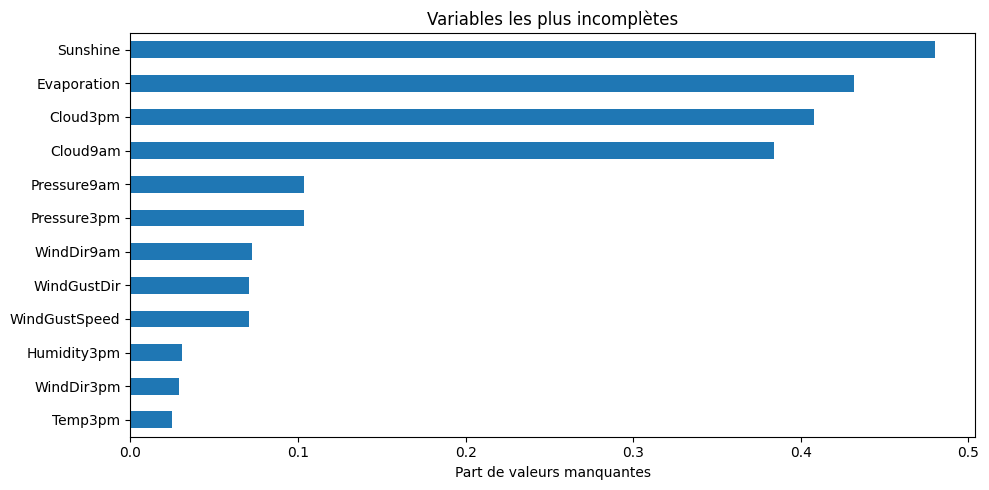

In [4]:
target_dist = (
    df["RainTomorrow"]
    .value_counts(dropna=False, normalize=True)
    .rename("proportion")
    .mul(100)
    .round(2)
)

display(target_dist)

missing_ratio = df.isna().mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
missing_ratio.head(12).sort_values().plot(kind="barh")
plt.title("Variables les plus incomplètes")
plt.xlabel("Part de valeurs manquantes")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Localisation des valeurs manquantes

Une partie des manques est très inégale selon les stations. On ajoute donc une lecture spatiale simple avec `folium`, en représentant pour quelques variables le volume de valeurs manquantes par station.

In [5]:
cols_to_map = ["Rainfall", "Evaporation", "Sunshine", "Cloud9am", "Cloud3pm"]

location_missing = build_location_missing_summary(df, cols_to_map)
location_missing.head()

,Location,Latitude,Longitude,Rainfall_NaN_count,Evaporation_NaN_count,Sunshine_NaN_count,Cloud9am_NaN_count,Cloud3pm_NaN_count
0,Adelaide,-34.928181,138.599931,102.0,1489.0,1424.0,3193.0,3193.0
1,Albany,-35.024782,117.883608,24.0,290.0,520.0,38.0,711.0
2,Albury,-36.073773,146.913526,29.0,3040.0,3040.0,1751.0,1613.0
3,AliceSprings,-23.698388,133.881289,8.0,215.0,520.0,334.0,361.0
4,BadgerysCreek,-33.883145,150.742466,81.0,3009.0,3009.0,3009.0,3009.0


In [6]:
maps = build_missing_value_maps(location_missing, cols_to_map, output_dir="maps_missing")

pd.Series(
    {col: f"maps_missing/australia_nan_{col}.html" for col in cols_to_map},
    name="fichier_html"
).to_frame()

,fichier_html
Rainfall,maps_missing/australia_nan_Rainfall.html
Evaporation,maps_missing/australia_nan_Evaporation.html
Sunshine,maps_missing/australia_nan_Sunshine.html
Cloud9am,maps_missing/australia_nan_Cloud9am.html
Cloud3pm,maps_missing/australia_nan_Cloud3pm.html


In [7]:
maps["Sunshine"]

## Quelques motifs simples avant nettoyage

On regarde ensuite deux éléments utiles pour la suite :
- la dépendance forte entre RainToday et RainTomorrow ;
- quelques profils saisonniers sur un petit groupe de villes.

In [13]:
pd.crosstab(
    df["RainToday"],
    df["RainTomorrow"],
    normalize="index"
)

RainTomorrow,No,Yes
RainToday,,
No,0.848132,0.151868
Yes,0.535940,0.464060


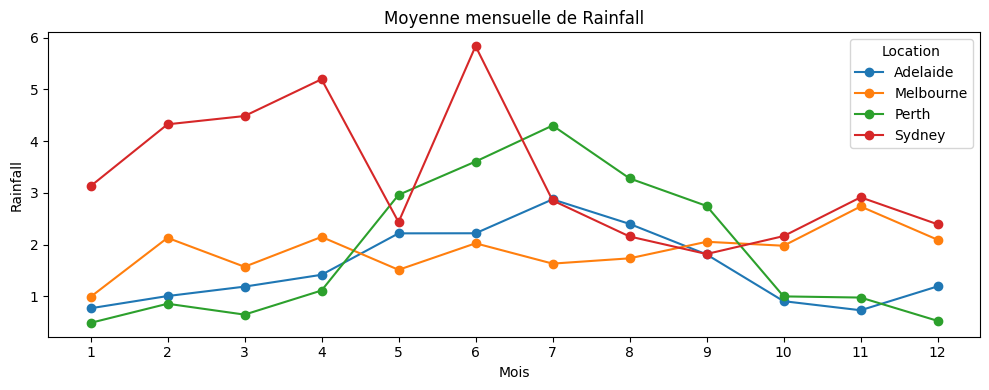

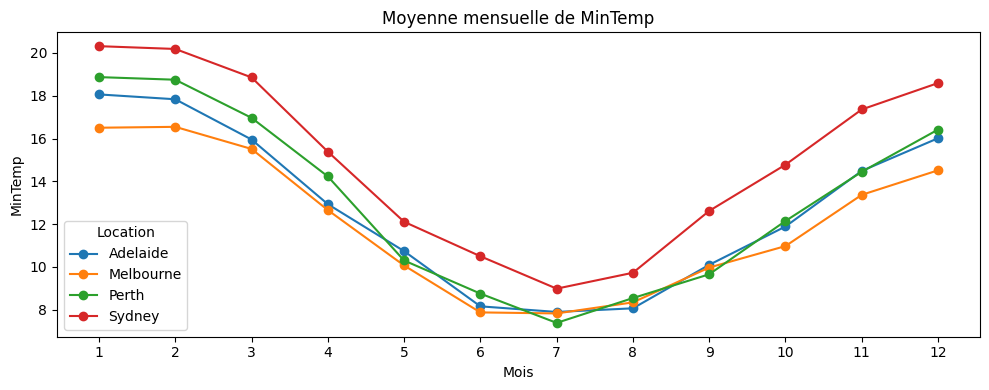

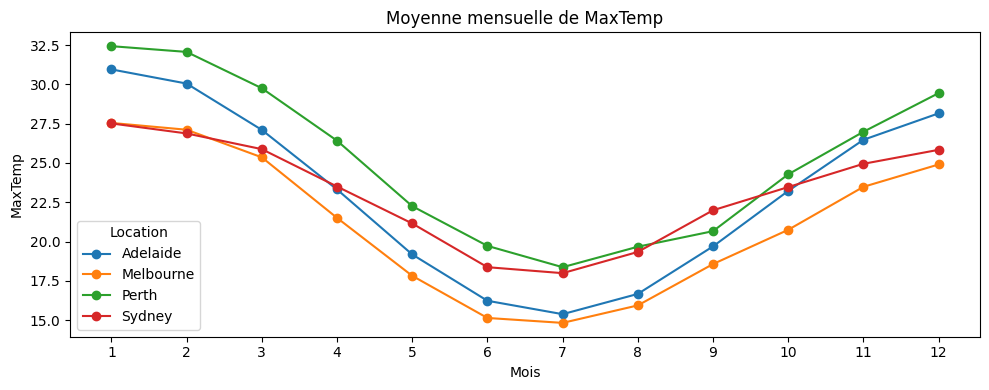

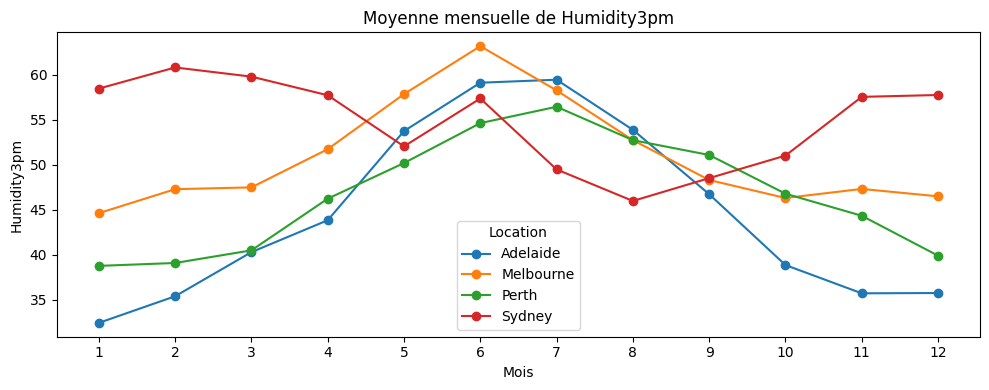

In [9]:
df_plot = df.copy()
df_plot["Month"] = df_plot["Date"].dt.month

cities = ["Sydney", "Melbourne", "Perth", "Adelaide"]
cols_to_plot = ["Rainfall", "MinTemp", "MaxTemp", "Humidity3pm"]

subset = df_plot[df_plot["Location"].isin(cities)]

for col in cols_to_plot:
    monthly = (
        subset.groupby(["Location", "Month"])[col]
        .mean()
        .reset_index()
        .pivot(index="Month", columns="Location", values=col)
    )

    monthly.plot(figsize=(10, 4), marker="o")
    plt.title(f"Moyenne mensuelle de {col}")
    plt.xlabel("Mois")
    plt.ylabel(col)
    plt.xticks(range(1, 13))
    plt.tight_layout()
    plt.show()

## Nettoyage

Le nettoyage reste volontairement simple et lisible :

- imputation par groupe Location × mois quand cela a du sens ;
- traitement un peu à part pour Rainfall, en s'appuyant sur les jours voisins dans une même station ;
- suppression de quelques variables très incomplètes que l'on n'utilisera pas dans les modèles de base ;
- correction légère de RainToday quand elle contredit manifestement Rainfall.

Pour éviter d'alourdir le notebook, la fonction de nettoyage est placée dans weather_cleaning.py.

In [10]:
df_clean = clean_weather_data(df)

missing_before = df.isna().mean().rename("brut")
missing_after = df_clean.isna().mean().rename("clean")
missing_compare = pd.concat([missing_before, missing_after], axis=1).sort_values("clean", ascending=False)

missing_compare.head(15)

,brut,clean
RainTomorrow,0.022460,0.02246
Location,0.000000,0.00000
Date,0.000000,0.00000
MinTemp,0.010209,0.00000
MaxTemp,0.008669,0.00000
WindGustDir,0.070989,0.00000
Rainfall,0.022419,0.00000
WindDir9am,0.072639,0.00000
WindDir3pm,0.029066,0.00000
WindSpeed9am,0.012148,0.00000


In [11]:
remaining_missing = df_clean.isna().mean().sort_values(ascending=False)
remaining_missing[remaining_missing > 0]

,0
RainTomorrow,0.02246


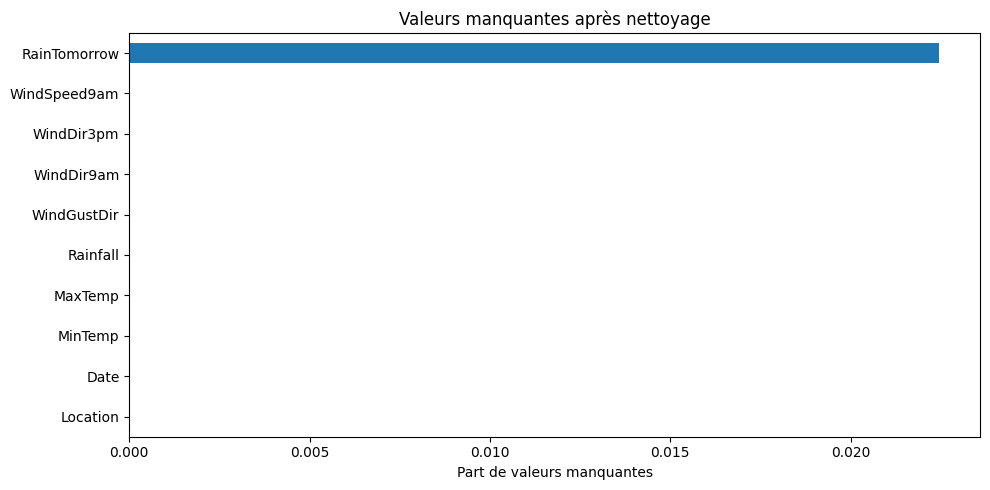

In [12]:
plt.figure(figsize=(10, 5))
(
    df_clean.isna().mean()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
    .plot(kind="barh")
)
plt.title("Valeurs manquantes après nettoyage")
plt.xlabel("Part de valeurs manquantes")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Export

On conserve  ici une version nettoyée assez générale.  
Le notebook suivant partira de df_clean.csv pour les modèles simples, tandis que le notebook sur CatBoost et le deep learning repartira du fichier brut avec un pré-traitement spécifique à chaque modèle.

In [ ]:
CLEAN_PATH = Path("df_clean.csv")
df_clean.to_csv(CLEAN_PATH, index=False)

print(f"Fichier enregistré : {CLEAN_PATH.resolve()}")
df_clean.head()

## Conclusion

Le nettoyage réduit fortement l'incomplétude du jeu de donnée.  
La carte des valeurs manquantes montre aussi que certains manques sont très localisé.

L'objectif ici reste surtout d'obtenir une base cohérente pour les premiers modèles, pas de figer un pipeline unique pour toutes les approches.